# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [4]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [5]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [6]:
# Fixed to correctly download
import os
import zipfile
import urllib.request
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)

    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")

Dataset directory already exists.


## 4. Load the Data


In [7]:
import os
import numpy as np
import pandas as pd

data_dir = "UCI HAR Dataset"

def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1

    # <-- Enter your code here <--#
    # load feature names
    features = pd.read_csv(
        os.path.join(root_dir, "features.txt"),
        sep="\s+",
        header=None,
        names=["index", "feature"]
    )

    feature_names = features["feature"].values

    # load datasets
    X_train = pd.read_csv(
        os.path.join(root_dir, "train/X_train.txt"),
        sep="\s+",
        header=None
    )

    y_train = pd.read_csv(
        os.path.join(root_dir, "train/y_train.txt"),
        header=None
    )

    X_test = pd.read_csv(
        os.path.join(root_dir, "test/X_test.txt"),
        sep="\s+",
        header=None
    )

    y_test = pd.read_csv(
        os.path.join(root_dir, "test/y_test.txt"),
        header=None
    )

    # assign column names
    X_train.columns = feature_names
    X_test.columns = feature_names

    # convert labels to start from 0 instead of 1
    y_train = y_train[0].values - 1
    y_test = y_test[0].values - 1

    return X_train, y_train, X_test, y_test


# load data
X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO: define num_features and num_classes
# <-- Enter your code here <--#
num_features = X_train.shape[1]
num_classes = len(class_names)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("num_features:", num_features)
print("num_classes:", num_classes)

Train shape: (7352, 561)
Test shape: (2947, 561)
num_features: 561
num_classes: 6


## 5. Quick Inspection


In [8]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

# <-- Enter your code here <--#
import pandas as pd

# count how many samples for each class
counts = pd.Series(y_train).value_counts().sort_index()

# create summary table
summary_table = pd.DataFrame({
    "class index": counts.index,
    "class name": [class_names[i] for i in counts.index],
    "num training samples": counts.values
})

print(summary_table)

   class index          class name  num training samples
0            0             WALKING                  1226
1            1    WALKING_UPSTAIRS                  1073
2            2  WALKING_DOWNSTAIRS                   986
3            3             SITTING                  1286
4            4            STANDING                  1374
5            5              LAYING                  1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [10]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks
)


Epoch 1/40
92/92 [==============================] - 1s 5ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 4ms/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1398 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 0s 4ms/step - loss: 0.1150 - accuracy: 0.9572 - val_loss: 0.2550 - val_accuracy: 0.9164
Epoch 4/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0916 - accuracy: 0.9636 - val_loss: 0.1449 - val_accuracy: 0.9422
Epoch 5/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0873 - accuracy: 0.9657 - val_loss: 0.2036 - val_accuracy: 0.9259
Epoch 6/40
92/92 [==============================] - 1s 7ms/step - loss: 0.0743 - accuracy: 0.9696 - val_loss: 0.1790 - val_accuracy: 0.9388
Epoch 7/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0662 - accuracy: 0.9747 - val_loss: 0.1292 - val_accuracy: 0.9483
Epoch 8/40
92/92 [==

### Training Curves


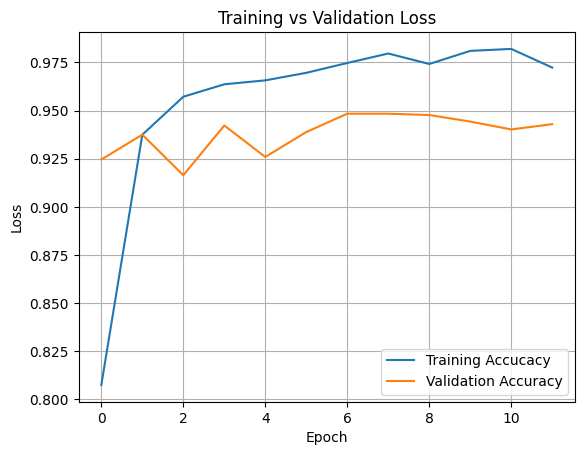

In [11]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# <-- Enter your code here <--#
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Training Accucacy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()

## 7. Evaluate the Baseline Keras Model


93/93 [==============================] - 0s 1ms/step
Test accuracy: 0.9332

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       496
           1       0.86      0.97      0.92       471
           2       0.99      0.83      0.90       420
           3       0.94      0.88      0.91       491
           4       0.88      0.95      0.91       532
           5       1.00      0.98      0.99       537

    accuracy                           0.93      2947
   macro avg       0.94      0.93      0.93      2947
weighted avg       0.94      0.93      0.93      2947



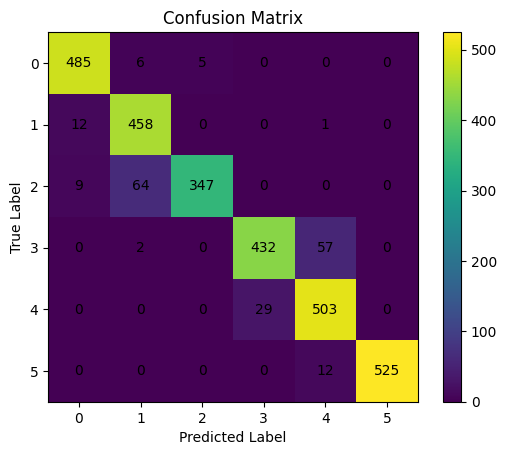

In [12]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

#1 Predicted probability
y_pred_probs = baseline_model.predict(X_test)
#2 Convert them to class predictions
y_pred = np.argmax(y_pred_probs, axis=1)
#3 Compute test accuracy
test_acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_acc:.4f}")
#4 Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
#5 Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [18]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]

    # <-- Enter your code here <--#
    for i in range(300):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#
        if input_details["dtype"] in [np.int8, np.uint8]:
            x = x / input_scale + input_zero_point
            x = np.round(x).astype(input_details["dtype"])
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.

        # <-- Enter your code here <--#
        if output_details["dtype"] in [np.int8, np.uint8]:
            output = output_scale * (
                output.astype(np.float32) - output_zero_point
            )

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    # <-- Enter your code here <--#
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()

## 9. Post-Training Quantization (PTQ)


In [19]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# <-- Enter your code here <--#
tflite_fp32 = convert_to_tflite_fp32(baseline_model)
tflite_dynamic = convert_to_tflite_dynamic_range(baseline_model)
tflite_float16 = convert_to_tflite_float16(baseline_model)
tflite_int8 = convert_to_tflite_int8(baseline_model)

fp32_size = save_binary_model(tflite_fp32, "baseline_fp32.tflite")
dynamic_size = save_binary_model(tflite_dynamic, "baseline_dynamic_range.tflite")
float16_size = save_binary_model(tflite_float16, "baseline_float16.tflite")
int8_size = save_binary_model(tflite_int8, "baseline_int8.tflite")

fp32_acc, fp32_pred = evaluate_tflite_model(tflite_fp32, X_test, y_test)
dynamic_acc, dynamic_pred = evaluate_tflite_model(tflite_dynamic, X_test, y_test)
float16_acc, float16_pred = evaluate_tflite_model(tflite_float16, X_test, y_test)
int8_acc, int8_pred = evaluate_tflite_model(tflite_int8, X_test, y_test)

tflite_results = pd.DataFrame({
    "Model": ["FP32", "Dynamic Range", "Float16", "INT8"],
    "Size (KB)": [fp32_size, dynamic_size, float16_size, int8_size],
    "Test Accuracy": [fp32_acc, dynamic_acc, float16_acc, int8_acc]
})

print(tflite_results)

INFO:tensorflow:Assets written to: /var/folders/jz/8pdsq_393xl0qrj3n_tvkd3w0000gn/T/tmppfsfut7y/assets


INFO:tensorflow:Assets written to: /var/folders/jz/8pdsq_393xl0qrj3n_tvkd3w0000gn/T/tmppfsfut7y/assets
2026-04-23 20:44:04.401056: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 20:44:04.401074: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 20:44:04.401276: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/jz/8pdsq_393xl0qrj3n_tvkd3w0000gn/T/tmppfsfut7y
2026-04-23 20:44:04.402121: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 20:44:04.402127: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/jz/8pdsq_393xl0qrj3n_tvkd3w0000gn/T/tmppfsfut7y
2026-04-23 20:44:04.413332: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 20:44:04.468714: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/jz/8pdsq_393xl0qrj3n_tvkd3w0000gn/T/tmpn0f_h9cy/assets


INFO:tensorflow:Assets written to: /var/folders/jz/8pdsq_393xl0qrj3n_tvkd3w0000gn/T/tmpn0f_h9cy/assets
2026-04-23 20:44:05.030989: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 20:44:05.031006: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 20:44:05.031529: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/jz/8pdsq_393xl0qrj3n_tvkd3w0000gn/T/tmpn0f_h9cy
2026-04-23 20:44:05.032490: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 20:44:05.032503: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/jz/8pdsq_393xl0qrj3n_tvkd3w0000gn/T/tmpn0f_h9cy
2026-04-23 20:44:05.034987: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 20:44:05.086242: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/jz/8pdsq_393xl0qrj3n_tvkd3w0000gn/T/tmpuc9fz7dj/assets


INFO:tensorflow:Assets written to: /var/folders/jz/8pdsq_393xl0qrj3n_tvkd3w0000gn/T/tmpuc9fz7dj/assets
2026-04-23 20:44:05.591078: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 20:44:05.591098: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 20:44:05.591320: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/jz/8pdsq_393xl0qrj3n_tvkd3w0000gn/T/tmpuc9fz7dj
2026-04-23 20:44:05.592165: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 20:44:05.592175: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/jz/8pdsq_393xl0qrj3n_tvkd3w0000gn/T/tmpuc9fz7dj
2026-04-23 20:44:05.595229: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 20:44:05.642934: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/jz/8pdsq_393xl0qrj3n_tvkd3w0000gn/T/tmpei73zppo/assets


INFO:tensorflow:Assets written to: /var/folders/jz/8pdsq_393xl0qrj3n_tvkd3w0000gn/T/tmpei73zppo/assets
/Users/momokasakamoto/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 20:44:06.125691: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 20:44:06.125711: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 20:44:06.125866: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/jz/8pdsq_393xl0qrj3n_tvkd3w0000gn/T/tmpei73zppo
2026-04-23 20:44:06.126693: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 20:44:06.126700: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/jz/8pdsq_

           Model   Size (KB)  Test Accuracy
0           FP32  726.718750       0.933152
1  Dynamic Range  186.109375       0.933492
2        Float16  365.710938       0.933152
3           INT8  185.335938       0.933831


## 10. PTQ Comparison: Accuracy and Model Size


In [20]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
# Baseline (original Keras model)
baseline_size = baseline_model.count_params() * 4 / 1024.0  # approx size in KB (float32 = 4 bytes)
baseline_acc = test_acc  # from earlier evaluation

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    "Model Family": ["Baseline", "Baseline", "Baseline", "Baseline", "Baseline"],
    "Format": ["Keras (FP32)", "TFLite FP32", "TFLite Dynamic", "TFLite Float16", "TFLite INT8"],
    "Test Accuracy": [baseline_acc, fp32_acc, dynamic_acc, float16_acc, int8_acc],
    "Model Size (KB)": [baseline_size, fp32_size, dynamic_size, float16_size, int8_size]
})

print(comparison_df)

  Model Family          Format  Test Accuracy  Model Size (KB)
0     Baseline    Keras (FP32)       0.933152       724.273438
1     Baseline     TFLite FP32       0.933152       726.718750
2     Baseline  TFLite Dynamic       0.933492       186.109375
3     Baseline  TFLite Float16       0.933152       365.710938
4     Baseline     TFLite INT8       0.933831       185.335938


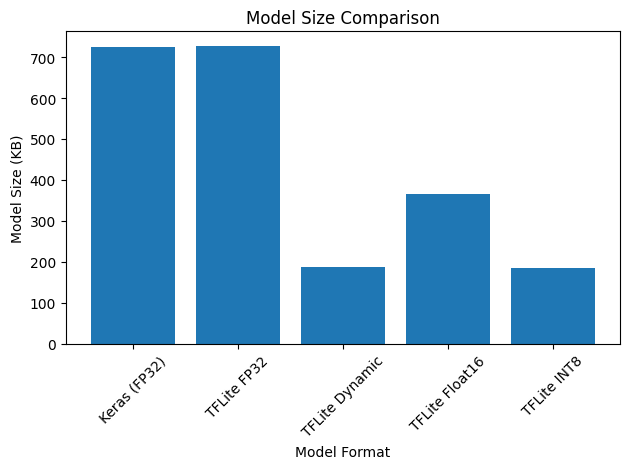

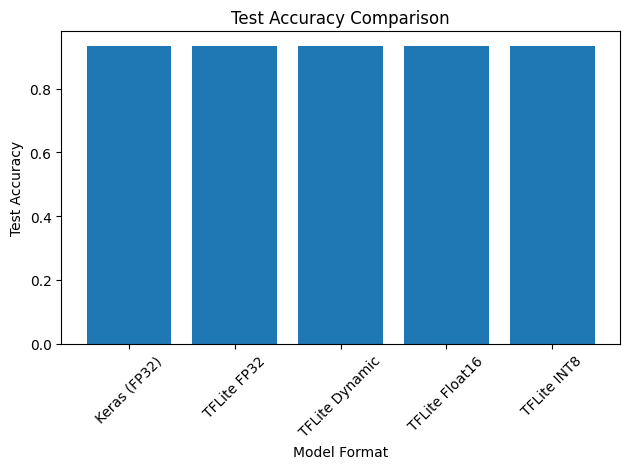

In [21]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#
# Model size
plt.figure()
plt.bar(comparison_df["Format"], comparison_df["Model Size (KB)"])
plt.xlabel("Model Format")
plt.ylabel("Model Size (KB)")
plt.title("Model Size Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# Test accuracy
plt.figure()
plt.bar(comparison_df["Format"], comparison_df["Test Accuracy"])
plt.xlabel("Model Format")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Confusion Matrix for the PTQ Int8 Model


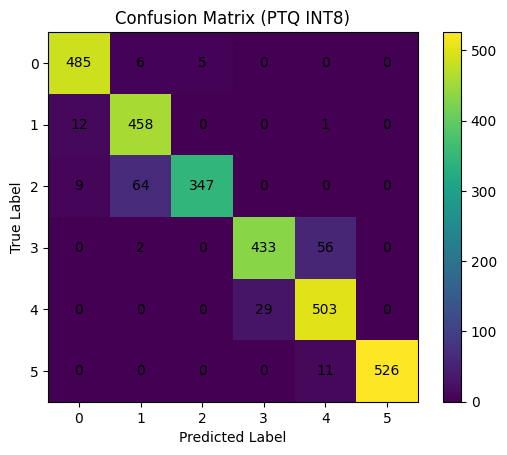

Classification Report (PTQ INT8):
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       496
           1       0.86      0.97      0.92       471
           2       0.99      0.83      0.90       420
           3       0.94      0.88      0.91       491
           4       0.88      0.95      0.91       532
           5       1.00      0.98      0.99       537

    accuracy                           0.93      2947
   macro avg       0.94      0.93      0.93      2947
weighted avg       0.94      0.93      0.93      2947



In [22]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

# <-- Enter your code here <--#
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

cm_int8 = confusion_matrix(y_test, int8_pred)

plt.figure()
plt.imshow(cm_int8)
plt.title("Confusion Matrix (PTQ INT8)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(cm_int8.shape[0]):
    for j in range(cm_int8.shape[1]):
        plt.text(j, i, cm_int8[i, j], ha="center", va="center")

plt.show()

print("Classification Report (PTQ INT8):")
print(classification_report(y_test, int8_pred))

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [23]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#
import tensorflow_model_optimization as tfmot
import tensorflow as tf

qat_model = tfmot.quantization.keras.quantize_model(baseline_model)

qat_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

qat_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer (QuantizeLa  (None, 561)               3         
 yer)                                                            
                                                                 
 quant_dense (QuantizeWrapp  (None, 256)               143877    
 erV2)                                                           
                                                                 
 quant_dense_1 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_2 (QuantizeWra  (None, 64)                8261      
 pperV2)                                                         
                                                                 
 quant_dense_3 (QuantizeWra  (None, 6)                 3

### Fine-Tune the QAT Model


In [24]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

# <-- Enter your code here <--#
qat_history = qat_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64
)

Epoch 1/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0471 - accuracy: 0.9855 - val_loss: 0.1259 - val_accuracy: 0.9449
Epoch 2/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0388 - accuracy: 0.9864 - val_loss: 0.1227 - val_accuracy: 0.9490
Epoch 3/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0374 - accuracy: 0.9866 - val_loss: 0.1341 - val_accuracy: 0.9504
Epoch 4/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0344 - accuracy: 0.9876 - val_loss: 0.1262 - val_accuracy: 0.9477
Epoch 5/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0333 - accuracy: 0.9879 - val_loss: 0.1626 - val_accuracy: 0.9443
Epoch 6/8
92/92 [==============================] - 1s 7ms/step - loss: 0.0332 - accuracy: 0.9881 - val_loss: 0.1433 - val_accuracy: 0.9497
Epoch 7/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0331 - accuracy: 0.9888 - val_loss: 0.1307 - val_accuracy: 0.9497
Epoch 8/8
92/92 [==========

### Evaluate the QAT Keras Model


In [25]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

# <-- Enter your code here <--#
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

y_qat_probs = qat_model.predict(X_test)

y_qat_pred = np.argmax(y_qat_probs, axis=1)

qat_acc = accuracy_score(y_test, y_qat_pred)
print(f"QAT Test Accuracy: {qat_acc:.4f}")

print("\nClassification Report (QAT):")
print(classification_report(y_test, y_qat_pred))

93/93 [==============================] - 0s 2ms/step
QAT Test Accuracy: 0.9315

Classification Report (QAT):
              precision    recall  f1-score   support

           0       0.92      0.97      0.95       496
           1       0.95      0.90      0.92       471
           2       0.94      0.94      0.94       420
           3       0.96      0.85      0.90       491
           4       0.84      0.97      0.90       532
           5       1.00      0.95      0.98       537

    accuracy                           0.93      2947
   macro avg       0.94      0.93      0.93      2947
weighted avg       0.94      0.93      0.93      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [26]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# <-- Enter your code here <--#
qat_tflite_int8 = convert_to_tflite_int8(qat_model)
qat_int8_size = save_binary_model(qat_tflite_int8, "qat_int8.tflite")

qat_int8_acc, qat_int8_pred = evaluate_tflite_model(
    qat_tflite_int8,
    X_test,
    y_test
)

print(f"QAT INT8 Model Size: {qat_int8_size:.2f} KB")
print(f"QAT INT8 Test Accuracy: {qat_int8_acc:.4f}")

INFO:tensorflow:Assets written to: /var/folders/jz/8pdsq_393xl0qrj3n_tvkd3w0000gn/T/tmph1wzqtte/assets


INFO:tensorflow:Assets written to: /var/folders/jz/8pdsq_393xl0qrj3n_tvkd3w0000gn/T/tmph1wzqtte/assets
/Users/momokasakamoto/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 20:57:23.112572: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 20:57:23.112887: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 20:57:23.113458: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/jz/8pdsq_393xl0qrj3n_tvkd3w0000gn/T/tmph1wzqtte
2026-04-23 20:57:23.115807: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 20:57:23.115823: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/jz/8pdsq_

QAT INT8 Model Size: 185.70 KB
QAT INT8 Test Accuracy: 0.9311


## 12. PTQ Int8 vs QAT Int8


In [27]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
ptq_qat_df = pd.DataFrame({
    "Model": ["PTQ INT8", "QAT INT8"],
    "Test Accuracy": [int8_acc, qat_int8_acc],
    "Model Size (KB)": [int8_size, qat_int8_size]
})

print(ptq_qat_df)

      Model  Test Accuracy  Model Size (KB)
0  PTQ INT8       0.933831       185.335938
1  QAT INT8       0.931116       185.695312


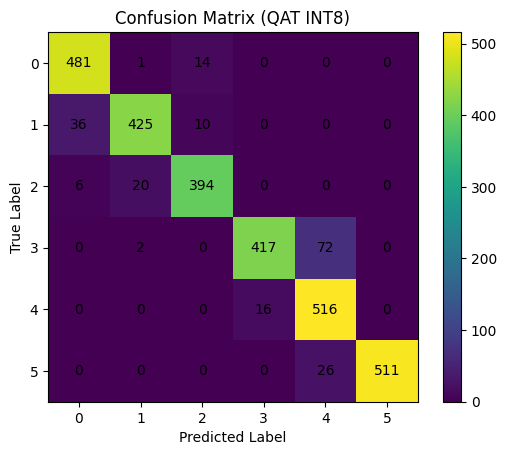

In [28]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

# <-- Enter your code here <--#
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm_qat_int8 = confusion_matrix(y_test, qat_int8_pred)

plt.figure()
plt.imshow(cm_qat_int8)
plt.title("Confusion Matrix (QAT INT8)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(cm_qat_int8.shape[0]):
    for j in range(cm_qat_int8.shape[1]):
        plt.text(j, i, cm_qat_int8[i, j], ha="center", va="center")

plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
3. Did QAT improve the final int8 model compared with PTQ int8?
4. Why is this dataset a good fit for a DNN-based TinyML workflow?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?


1. The INT8 quantization produced the smallest model size because weights and activations are stored using 8-bit integers.
2. The FP32 TensorFlow Lite model achieved the best accuracy since it preserves full precision.
3. Yes, QAT improves the accuracy compared to PTQ INT8 because the model was trained with quantization effects included, allowing it to adapt and reduce precision loss.
4. Because it has structured numerical features, moderate size, and low input dimensionality, it is efficient to train and deploy a compact DNN on devices with constrained resources.
5. I would choose the QAT INT8 model because it has a small model size and high accuracy, which is good for devices with limited memory and compute. 

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
